# 06 - Select Top N Classes

Filters the dataset to the TOP_K most frequent classes (`label`) and saves the result under a fixed output name for downstream use.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video.csv'
TOP_K = 50

OUTPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_classes.csv'
OUTPUT_LABELS_CSV = PROJECT_ROOT / 'merged_datasets' / 'topn_labels.csv'

print('INPUT_CSV:', INPUT_CSV)
print('OUTPUT_CSV:', OUTPUT_CSV)
print('OUTPUT_LABELS_CSV:', OUTPUT_LABELS_CSV)
print('TOP_K:', TOP_K)

INPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video.csv
OUTPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_topn_classes.csv
OUTPUT_LABELS_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\topn_labels.csv
TOP_K: 50


In [3]:
df = pd.read_csv(INPUT_CSV)

print('Shape:', df.shape)
print('Unique classes:', df['label'].nunique())

display(df.head())

Shape: (12140, 12)
Unique classes: 2000


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,book,aslbrick,kaggle_dataset/videos/69241.mp4,1,75.0,75.0,2.502,29.97003,118,True,1280.0,720.0
1,book,valencia-asl,kaggle_dataset/videos/68011.mp4,1,NaN,NaN,NaN,25.00000,110,True,NaN,NaN
2,book,valencia-asl,kaggle_dataset/videos/68012.mp4,1,NaN,NaN,NaN,25.00000,109,True,NaN,NaN
3,book,northtexas,kaggle_dataset/videos/70212.mp4,2150,2249.0,100.0,4.000,25.00000,121,True,NaN,NaN
4,book,northtexas,kaggle_dataset/videos/70266.mp4,3732,3852.0,121.0,4.840,25.00000,121,True,NaN,NaN


In [4]:
label_counts = df['label'].value_counts()
topn_labels = label_counts.head(TOP_K).index.tolist()

topn_df = df[df['label'].isin(topn_labels)].copy()
topn_counts = topn_df['label'].value_counts()

print('Classes after filtering:', topn_df['label'].nunique())
print('Shape after filtering:', topn_df.shape)

display(topn_counts.to_frame('count').head(TOP_K))

Classes after filtering: 50
Shape after filtering: (648, 12)


,count
label,
computer,18
drink,16
before,16
like,16
hot,15
orange,15
mother,14
yes,14
deaf,14


In [5]:
topn_df.to_csv(OUTPUT_CSV, index=False)
pd.DataFrame({'label': topn_labels}).to_csv(OUTPUT_LABELS_CSV, index=False)

print('Saved:')
print('-', OUTPUT_CSV)
print('-', OUTPUT_LABELS_CSV)

Saved:
- C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_topn_classes.csv
- C:\Users\Magda\source\repos\private\szum\merged_datasets\topn_labels.csv


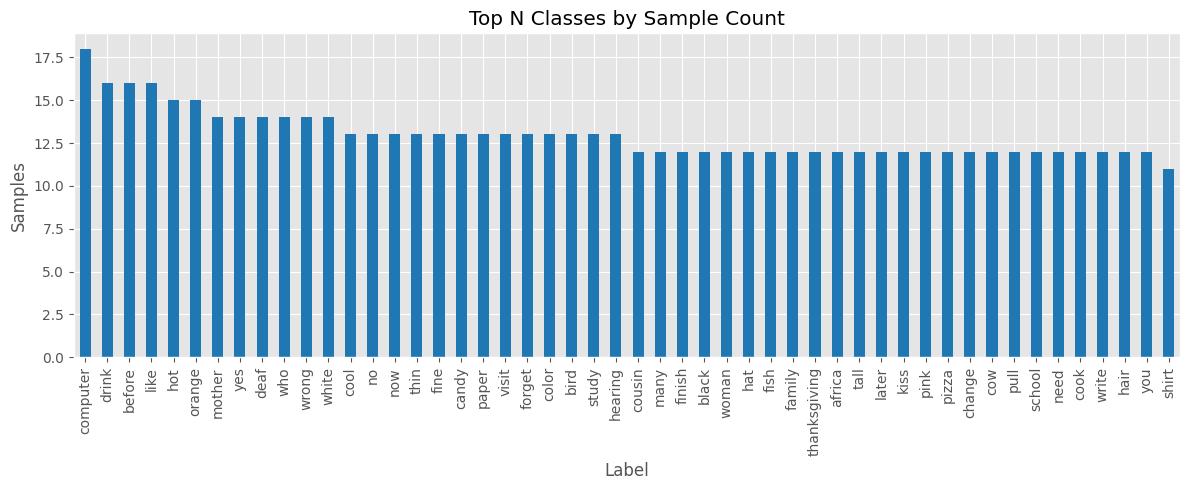

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
topn_counts.sort_values(ascending=False).plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Top N Classes by Sample Count')
ax.set_xlabel('Label')
ax.set_ylabel('Samples')
plt.tight_layout()
plt.show()